In [ ]:
import os
import numpy as np
from sklearn.cluster import SpectralClustering
import cvxpy as cp
import mosek

import utils

SAVE = False
PREFIX = './results/opt_lamb'

# Check restuls dir exists and create
if not os.path.exists(PREFIX):
    os.makedirs(PREFIX)

## Load and plot data

Shape of: X: (122, 1214)  -  Y: (2, 1214)  -  data: (124, 1214)
(Min, Max) values of: X: (-7.201, 18.151)  - Y: (-1.731, 1.732)  -  data: (-7.201, 18.151)
Mean value of: X: 0.000  -  Y: -0.000  -  data: 0.000
Std value of: X: 1.000  -  Y: 1.000  -  data: 1.000


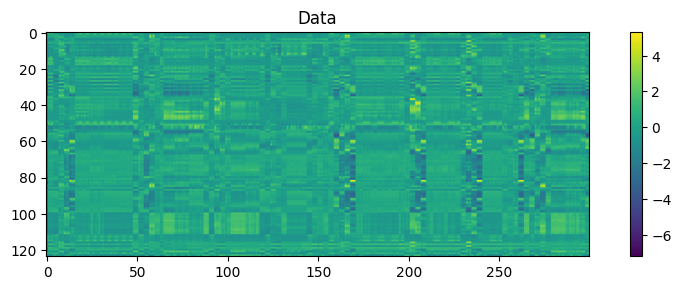

In [2]:
Data = utils.load_accoustic_data(all_data=True)
N, M = Data.shape

## Learn undirected SEM with negative edges

In [3]:
# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

Mults = np.concatenate( [np.linspace(0, 500, 15), np.linspace(550, 7.5e3, 15), np.linspace(1e4, 5e4, 5)] )
A_undir_sem = []
for mult in Mults:
    lamb = mult*lamb0

    A = cp.Variable((N,N), symmetric=True)
    obj = cp.sum_squares(A@Data - Data) + lamb*cp.sum(cp.abs(A))
    constr = [ cp.abs( A[np.eye(N, dtype=bool)] ) <= 1e-6 ]

    prob = cp.Problem(cp.Minimize(obj), constr)
    obj = prob.solve(solver='MOSEK', verbose=False)

    A_est = A.value
    # A_est /= np.max(np.abs(A_est))
    norm_A = np.linalg.norm(A_est.flatten(), 1)

    print(f'Lamb (mult): {lamb:.4f} ({mult})  - status: {prob.status} - norm A: {norm_A:.4f}')

    A_undir_sem.append(A_est)
    


Lamb (mult): 0.0000 (0.0)  - status: optimal - norm A: 922.4178
Lamb (mult): 2.2504 (35.714285714285715)  - status: optimal - norm A: 661.9265
Lamb (mult): 4.5009 (71.42857142857143)  - status: optimal - norm A: 555.4769
Lamb (mult): 6.7513 (107.14285714285714)  - status: optimal - norm A: 496.4952
Lamb (mult): 9.0018 (142.85714285714286)  - status: optimal - norm A: 455.9674
Lamb (mult): 11.2522 (178.57142857142858)  - status: optimal - norm A: 425.3486
Lamb (mult): 13.5027 (214.28571428571428)  - status: optimal - norm A: 401.0841
Lamb (mult): 15.7531 (250.0)  - status: optimal - norm A: 381.0080
Lamb (mult): 18.0036 (285.7142857142857)  - status: optimal - norm A: 364.0760
Lamb (mult): 20.2540 (321.42857142857144)  - status: optimal - norm A: 349.6005
Lamb (mult): 22.5045 (357.14285714285717)  - status: optimal - norm A: 336.8739
Lamb (mult): 24.7549 (392.8571428571429)  - status: optimal - norm A: 325.2300
Lamb (mult): 27.0054 (428.57142857142856)  - status: optimal - norm A: 314.9

### Plot error without thresholding

Max number of links: 7626.0
Number of links (whole graph):
[3107. 2051. 1651. 1445. 1293. 1194. 1114. 1045.  984.  936.  910.  881.
  859.  835.  804.  788.  620.  526.  463.  425.  392.  362.  341.  322.
  300.  284.  273.  260.  244.  231.  190.   90.   35.    0.    0.]


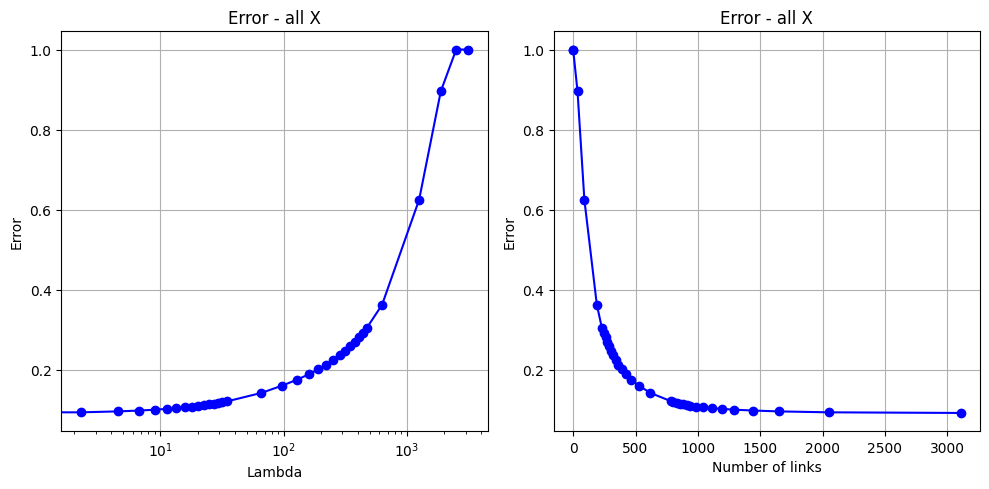

	 Saved as: ./results/opt_lamb/sem_und_noth_err
Max number of links: 245


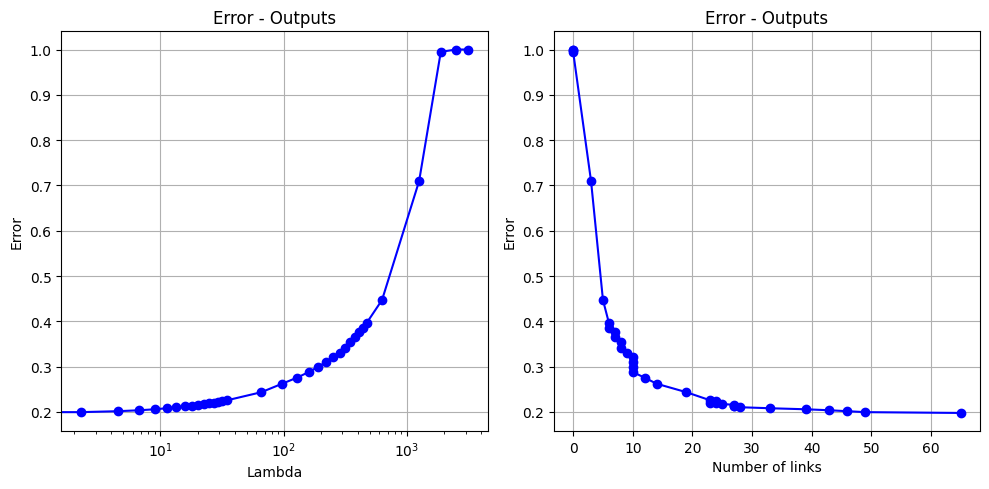

	 Saved as: ./results/opt_lamb/sem_und_noth_err_out
Number of links (only output):
[65. 49. 46. 43. 39. 33. 28. 27. 27. 27. 25. 24. 23. 24. 24. 23. 19. 14.
 12. 10. 10. 10. 10.  9.  8.  8.  7.  7.  6.  6.  5.  3.  0.  0.  0.]


In [4]:
th = 0.05
lambdas = Mults*lamb0
N = Data.shape[0]

file_name = f'{PREFIX}/sem_und_noth_err'

## For all variables
print('Max number of links:', N*(N-1)/2)
err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=False)
print('Number of links (whole graph):')
print(sparsity)

utils.save_plot_err_sparsity(lambdas, err, sparsity, file_name=file_name, save=SAVE, logx=True)

## For output variables
target = np.arange(122,124)
print('Max number of links:', 2*(N-1)-1)
err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=False, target_idx=target)
utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Outputs', file_name=file_name+'_out', save=SAVE, logx=True)
print('Number of links (only output):')
print(sparsity)

# ## For output 122
# target = 122
# print('Max number of links:', 2*(N-1)-1)
# err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=False, target_idx=target)
# utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Output 122', file_name=file_name+'_out122', save=SAVE)

# ## For output 123
# target = 123
# print('Max number of links:', 2*(N-1)-1)
# err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=False, target_idx=target)
# utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Output 123', file_name=file_name+'_out123', save=SAVE)

In [5]:
# import pandas as pd

# # files = ['sem_und_noth_err_out', 'sem_und_noth_err_out122', 'sem_und_noth_err_out123', 'sem_und_noth_err',
# #          'sem_und_withth_err_out', 'sem_und_withth_err_out122', 'sem_und_withth_err_out123', 'sem_und_withth_err']
# files = ['sem_und_noth_err_out', 'sem_und_noth_err', 'sem_und_withth_err']
# for sufix in files:
#     file_name = PREFIX + '/' + sufix + '.npz'
#     lamb0 = np.sqrt(np.log(N)/M)
#     data = np.load(file_name)  # O "file.npz" si usaste esa extensión

#     err = data['err']
#     sparsity = data['sparsity']
#     lambdas = data['lambdas']

#     df = pd.DataFrame({key: data[key] for key in data.files})
#     csv_file = PREFIX + '/' + sufix + '.csv'
#     df.to_csv(csv_file, index=False)
#     print(csv_file)


### Plot error with threshold

Max number of links: 7626.0


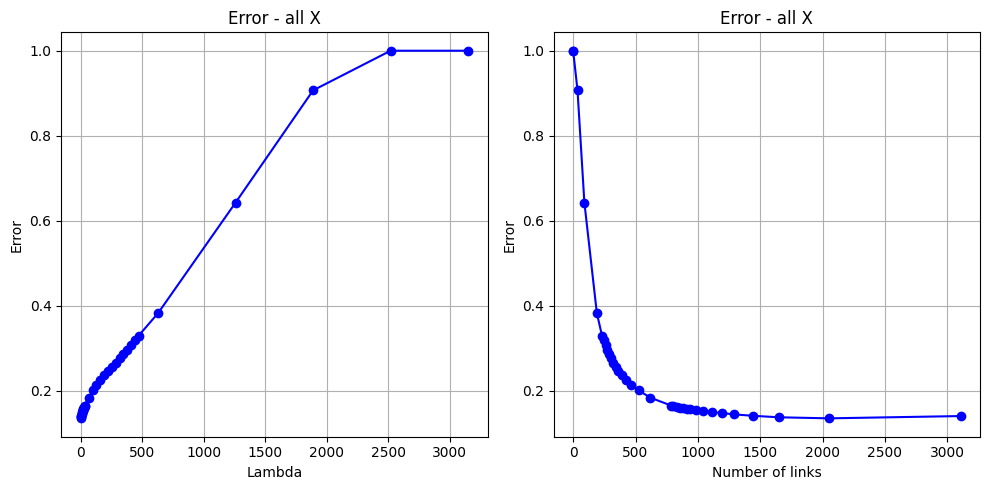

Max number of links: 245


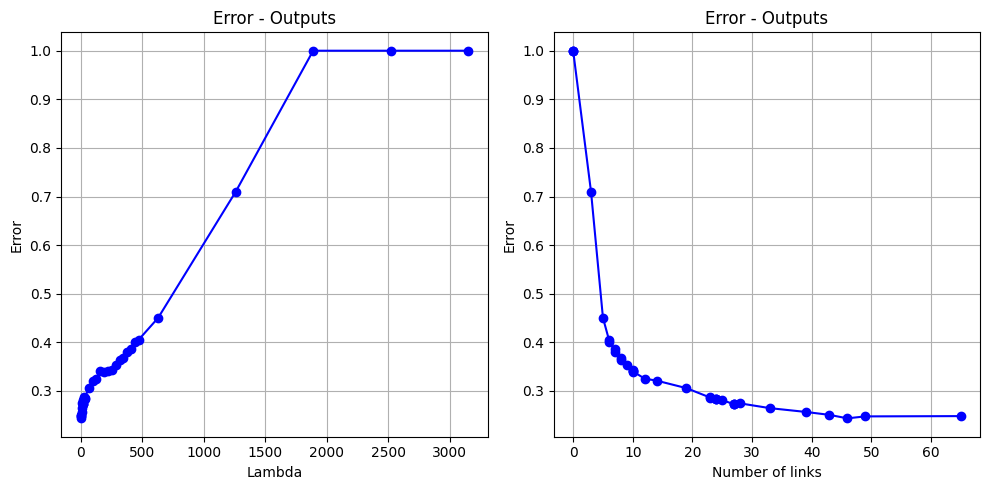

In [6]:
th = 0.05
lambdas = Mults*lamb0
N = Data.shape[0]

file_name = f'{PREFIX}/sem_und_withth_err'

## For all variables
print('Max number of links:', N*(N-1)/2)
err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=True)
utils.save_plot_err_sparsity(lambdas, err, sparsity, file_name=file_name, save=False)

## For output variables
target = np.arange(122,124)
print('Max number of links:', 2*(N-1)-1)
err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=True, target_idx=target)
utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Outputs', file_name=file_name+'_out', save=False)

# ## For output 122
# target = 122
# print('Max number of links:', 2*(N-1)-1)
# err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=True, target_idx=target)
# utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Output 122', file_name=file_name+'_out122', save=SAVE)

# ## For output 123
# target = 123
# print('Max number of links:', 2*(N-1)-1)
# err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=True, target_idx=target)
# utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Output 123', file_name=file_name+'_out123', save=SAVE)

## Learn unconnected SEM with negative edges

In [7]:
# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

# Mults = np.concatenate( [np.linspace(0, 500, 15), np.linspace(550, 1e4, 15), np.logspace(4, 5, 3)] )
Mults = np.concatenate( [np.linspace(0, 500, 15), np.linspace(550, 7.5e3, 15), np.linspace(1e4, 5e4, 5)] )
A_undir_sem = []
for mult in Mults:
    lamb = mult*lamb0

    A = cp.Variable((N,N), symmetric=True)
    obj = cp.sum_squares(A@Data - Data) + lamb*cp.sum(cp.abs(A))
    # constr = [A[np.eye(N, dtype=bool)] == 0, A[-1,-2] == 0, A[-2,-1] == 0]
    constr = [ cp.abs( A[np.eye(N, dtype=bool)] ) <= 1e-6,
               cp.abs( A[-1,-2] ) <= 1e-6]

    prob = cp.Problem(cp.Minimize(obj), constr)
    obj = prob.solve(solver='MOSEK', verbose=False)

    A_est = A.value
    # A_est /= np.max(np.abs(A_est))
    norm_A = np.linalg.norm(A_est.flatten(), 1)

    print(f'Lamb (mult): {lamb:.4f} ({mult})  - status: {prob.status} - norm A: {norm_A:.4f}')

    A_undir_sem.append(A_est)
    


Lamb (mult): 0.0000 (0.0)  - status: optimal - norm A: 923.4089
Lamb (mult): 2.2504 (35.714285714285715)  - status: optimal - norm A: 662.5943
Lamb (mult): 4.5009 (71.42857142857143)  - status: optimal - norm A: 556.0001
Lamb (mult): 6.7513 (107.14285714285714)  - status: optimal - norm A: 497.2185
Lamb (mult): 9.0018 (142.85714285714286)  - status: optimal - norm A: 456.7406
Lamb (mult): 11.2522 (178.57142857142858)  - status: optimal - norm A: 426.2278
Lamb (mult): 13.5027 (214.28571428571428)  - status: optimal - norm A: 402.0455
Lamb (mult): 15.7531 (250.0)  - status: optimal - norm A: 381.9608
Lamb (mult): 18.0036 (285.7142857142857)  - status: optimal - norm A: 364.9788
Lamb (mult): 20.2540 (321.42857142857144)  - status: optimal - norm A: 350.4755
Lamb (mult): 22.5045 (357.14285714285717)  - status: optimal - norm A: 337.6451
Lamb (mult): 24.7549 (392.8571428571429)  - status: optimal - norm A: 326.0829
Lamb (mult): 27.0054 (428.57142857142856)  - status: optimal - norm A: 315.7

### Plot error without thresholding

Max number of links: 7626.0
Number of links (whole graph):
[3106. 2066. 1654. 1444. 1298. 1204. 1126. 1062.  996.  950.  922.  896.
  867.  841.  811.  794.  627.  530.  466.  423.  394.  363.  343.  324.
  302.  284.  273.  260.  245.  228.  189.   90.   35.    0.    0.]


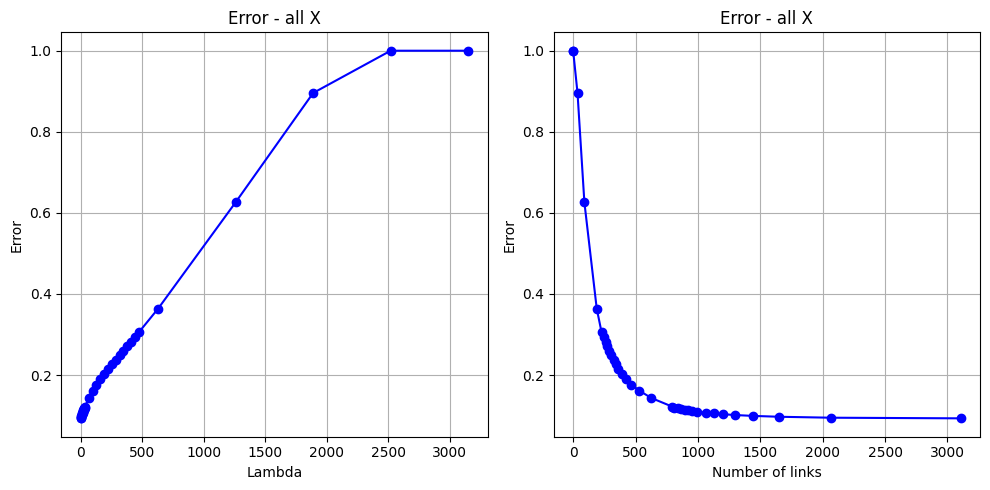

	 Saved as: ./results/opt_lamb/sem_unc_noth_err
Max number of links: 245
Number of links (only output):
[73. 52. 46. 43. 40. 38. 38. 38. 35. 35. 35. 33. 32. 31. 28. 28. 22. 19.
 15. 13. 12. 12. 12. 11. 10.  9.  8.  8.  8.  6.  5.  2.  0.  0.  0.]


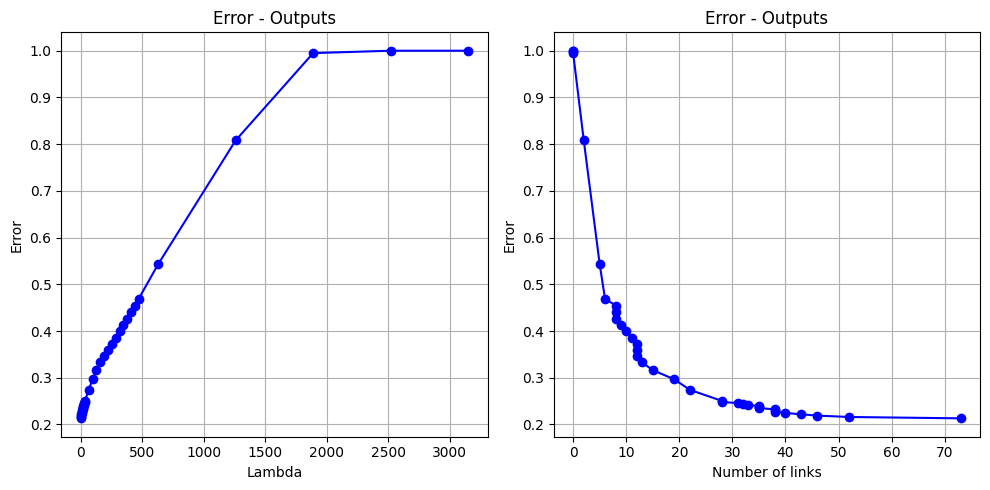

	 Saved as: ./results/opt_lamb/sem_unc_noth_err_out


In [8]:
th = 0.05
lambdas = Mults*lamb0
N = Data.shape[0]

file_name = f'{PREFIX}/sem_unc_noth_err'

## For all variables
print('Max number of links:', N*(N-1)/2)
err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=False)
print('Number of links (whole graph):')
print(sparsity)

utils.save_plot_err_sparsity(lambdas, err, sparsity, file_name=file_name, save=SAVE)

## For output variables
target = np.arange(122,124)
print('Max number of links:', 2*(N-1)-1)
err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=False, target_idx=target)

print('Number of links (only output):')
print(sparsity)

utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Outputs', file_name=file_name+'_out', save=SAVE)


# ## For output 122
# target = 122
# print('Max number of links:', 2*(N-1)-1)
# err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=False, target_idx=target)
# utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Output 122', file_name=file_name+'_out122', save=SAVE)

# ## For output 123
# target = 123
# print('Max number of links:', 2*(N-1)-1)
# err, sparsity = utils.compute_err_sparsity(A_undir_sem, Data, th, th_err=False, target_idx=target)
# utils.save_plot_err_sparsity(lambdas, err, sparsity, title='Error - Output 123', file_name=file_name+'_out123', save=SAVE)